In [4]:
import jax

# jax.config.update("jax_enable_x64", False)
jax.config.update("jax_enable_x64", True)
# jax.config.update("jax_platform_name", "cpu")
jax.config.update("jax_platform_name", "gpu")
print(jax.local_devices()[0].device_kind)
from jax import numpy as np, random as jr, tree as jtu
import os


import zodiax as zdx
from zodiax.optimisation import sgd, adam
import dLux.utils as dlu

from amigo.fitting import Trainer
import dorito


# visualisation
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots
import cmasher as cmr

# matplotlib parameters
plt.style.use(["science", "bright", "no-latex"])

plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

inferno = mpl.colormaps["inferno"]
viridis = mpl.colormaps["viridis"]
seismic = mpl.colormaps["seismic"]
coolwarm = mpl.colormaps["coolwarm"]

inferno.set_bad("k", 0.5)
viridis.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)
coolwarm.set_bad("k", 0.5)

NVIDIA GeForce RTX 2080 Ti


In [5]:
from socket import gethostname

if gethostname() == "glinton":
    morgana = "/media/morgana1/"
else:
    morgana = "/Volumes/morgana1/"

amigo_cache = os.path.join(morgana, "snert/max/data/amigo_files/")

cache = os.path.join(amigo_cache, "v_0.0.10/")
output_path = os.path.join(amigo_cache, "outputs/GTO1242/")

load_dict = lambda x: np.load(x, allow_pickle=True).item()
cal_vis_outputs = load_dict(os.path.join(output_path, "bgmask_cal_vis_pds70.npy"))

print(cal_vis_outputs.keys())

dict_keys(['F380M', 'F430M', 'F480M'])


In [6]:
from scipy.ndimage import binary_dilation


class MCAOIFit(dorito.model_fits.ResolvedOIFit):

    def initialise_params(self, model, distribution, contrast=0.949):

        params = {}  # Initialise an empty dictionary for parameters

        # resolved component distributino
        distribution = (distribution.flatten())[~model.moat]
        distribution *= (
            1 - contrast
        ) / distribution.sum()  # normalise the distribution

        log_dist = np.log10(distribution)
        params["log_dist"] = self.get_key("log_dist"), log_dist

        # the star component
        params["contrast"] = self.get_key("contrast"), np.array(contrast)

        # Fourier normalisation (not to be optimised)
        params["base_uv"] = self.get_key("base_uv"), self.get_base_uv(
            model, distribution.shape[0]
        )
        params
        return params

    def get_key(self, param):

        match param:
            case "contrast":
                return self.filter

        return super().get_key(param)

    def map_param(self, param):

        # Map the appropriate parameter to the correct key
        if param in ["log_dist", "base_uv", "contrast"]:
            return f"{param}.{self.get_key(param)}"

        # Else its global
        return param

    def __call__(self, model, rotate=False):
        return super().__call__(model, rotate=rotate)


class MCADiscoModel(dorito.models.ResolvedDiscoModel):

    size: int = None
    moat: np.ndarray = None  # Placeholder for the moat attribute
    star: np.ndarray = None  # Placeholder for the star attribute

    def __init__(
        self,
        ois: list,
        distribution: np.ndarray,
        uv_npixels: int,
        uv_pscale: float,
        oversample: float = 1.0,
        psf_pixel_scale: float = 0.065524085,  # arcsec/pixel
        moat_width: int = 3,
    ):

        dist_shape = distribution.shape
        zeros = np.zeros(dist_shape).flatten()
        star = zeros.at[zeros.size // 2].set(True)

        moat_mask = binary_dilation(
            star.reshape(dist_shape), iterations=moat_width
        ).flatten()
        # Precompute safe indices for use in JIT-compiled code
        self.moat = np.where(~moat_mask)[0]  # shape (N,)

        self.star = star
        self.size = dist_shape[0]

        super().__init__(
            ois,
            distribution,
            uv_npixels,
            uv_pscale,
            oversample,
            psf_pixel_scale,
        )

    def get_distribution(self, exposure, rotate=False, with_star=True):
        """
        Get the distribution from the exposure.

        Args:
            exposure: The exposure object containing the distribution key.
        Returns:
            Array: The intensity distribution of the source.
        """

        zeros = np.zeros(self.size * self.size)
        values = 10 ** self.params["log_dist"][exposure.get_key("log_dist")]
        contrast = self.params["contrast"][exposure.get_key("contrast")]

        resolved_component = (
            zeros.at[self.moat].set(values).reshape((self.size, self.size))
        )

        if with_star:
            star_component = contrast * self.star.reshape((self.size, self.size))
            distribution = resolved_component + star_component
        else:
            distribution = resolved_component

        if rotate:
            distribution = exposure.rotate(distribution)

        return distribution

In [7]:
def gaussian_2d(shape, center=None, sigma=10, order=2):
    y = np.arange(shape[0])
    x = np.arange(shape[1])
    x, y = np.meshgrid(x, y)
    if center is None:
        center = (shape[1] // 2, shape[0] // 2)

    r2 = (x - center[0]) ** 2 + (y - center[1]) ** 2
    r = np.sqrt(r2)

    supergauss = np.exp(-(r**order) / (2 * sigma**order))
    return supergauss / supergauss.max()

In [8]:
optics_diameter = 6.603464  # JWST aperture diameter in meters
otf_coords = dlu.pixel_coords(51, 2 * optics_diameter)

ois = [MCAOIFit(oi_data, key, filter=key) for key, oi_data in cal_vis_outputs.items()]
ois = [ois[-1]]
for oi in ois:
    print(oi.key)

s = 111
distribution = np.ones((s, s))
# distribution *= gaussian_2d((s, s), sigma=15, order=2)


model = MCADiscoModel(
    ois,
    distribution,
    uv_npixels=2 * otf_coords.shape[-1],
    uv_pscale=0.5 * np.diff(otf_coords[0, 0]).mean(),
    oversample=3.0,
    moat_width=1,
)

# # Initialise at the mean dirty image
# # otf = np.load("files/otf_support.npy")
# otf = None

# params = {"log_dist": {}, "base_uv": model.params["base_uv"]}
# hypot = lambda x: np.sqrt(np.array([_x**2 for _x in x]).sum(0))
# for filt in ["F380M", "F430M", "F480M"]:
#     dirty_imgs = [
#         oi.dirty_image(model, rotate=False, otf_support=otf, pad=200)
#         for oi in ois
#         if oi.filter == filt
#     ]

#     if dirty_imgs == []:
#         print(f"No dirty images for filter {filt}, skipping initialisation.")
#         continue
#     mean_dirty = hypot(dirty_imgs)
#     init_dist = np.log10(mean_dirty / mean_dirty.sum() + 1e-16)
#     for oi in ois:
#         if oi.filter == filt:
#             params["log_dist"][oi.get_key("log_dist")] = init_dist

# model = model.set("params", params)

F480M


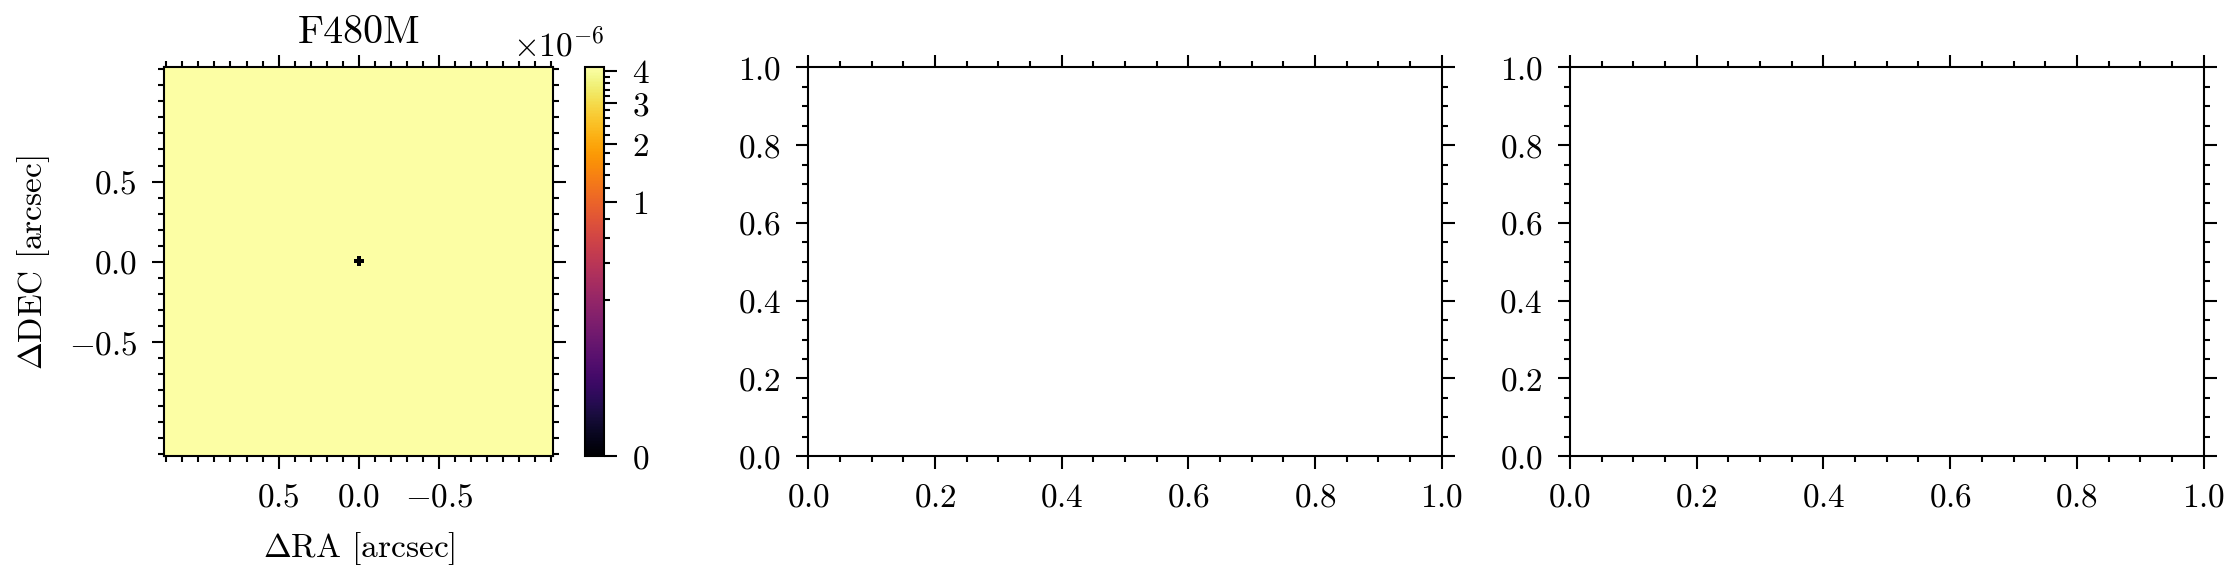

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(8, 2))

for idx, oi in enumerate(ois):

    init_dist = model.get_distribution(oi)

    c0 = dorito.plotting.plot_result(
        ax[idx],
        init_dist.at[init_dist.shape[0] // 2, init_dist.shape[1] // 2].set(np.nan),
        pixel_scale=dlu.rad2arcsec(model.pscale_in),
        cmap=inferno,
        norm=mpl.colors.PowerNorm(0.3),
    )
    fig.colorbar(c0, ax=ax[idx])
    ax[idx].set(title=oi.filter)

plt.tight_layout()
plt.show()

In [10]:
def normalise_distribution(model_params, args):
    params = model_params.params

    for filt in params["log_dist"].keys():

        log_dist = params["log_dist"][filt]
        contrast = params["contrast"][filt]

        dist = 10**log_dist

        # normalising the distribution
        params["log_dist"][filt] = np.log10(dist * (1 - contrast) / dist.sum())

    return model_params.set("params", params), args


def looper(looper, loss_dict):
    loss = np.array([v[-1] for v in loss_dict.values()]).mean(0)
    looper.set_description(f"Loss: {loss:.3e}")


from amigo.calibration import get_temperature, get_warmup


def grads_fn(model, grads, args):
    # Get the parameters
    grad_params = grads.params

    # Get the key and update args with new key
    key, subkey = jr.split(args["key"], 2)
    args["key"] = subkey

    # Adds a temperature to the NN gradients
    for filt in grad_params["log_dist"].keys():
        values = grad_params["log_dist"][filt]
        rand_vals = get_temperature(args) * jr.normal(key, values.shape)
        values += rand_vals

        grad_params["log_dist"][filt] = values

    # for filt in grad_params["contrast"].keys():
    #     values = grad_params["contrast"][filt]
    #     # Add the learning rate warm-up
    #     values *= get_warmup(args)

    # Increment the t parameter
    args["t"] += 1.0

    grads = grads.set("params", grad_params)
    return grads, args

In [11]:
def ME(model, exposure):
    return dorito.stats.ME_loss(model.get_distribution(exposure, with_star=False))


def TV_loss(arr, eps=1e-16):
    """
    Total variation loss function.
    """
    # Backward finite differences
    dx = arr[:, 1:] - arr[:, :-1]  # horizontal diffs
    dy = arr[1:, :] - arr[:-1, :]  # vertical diffs

    # TV = sum over sqrt(dx² + dy² + eps²)
    tv_x = np.sqrt(dx**2 + eps**2)
    tv_y = np.sqrt(dy**2 + eps**2)

    return tv_x.sum() + tv_y.sum()


def TV(model, exposure):
    return TV_loss(model.get_distribution(exposure, with_star=False))


def TSV(model, exposure):
    return dorito.stats.TSV_loss(model.get_distribution(exposure, with_star=False))

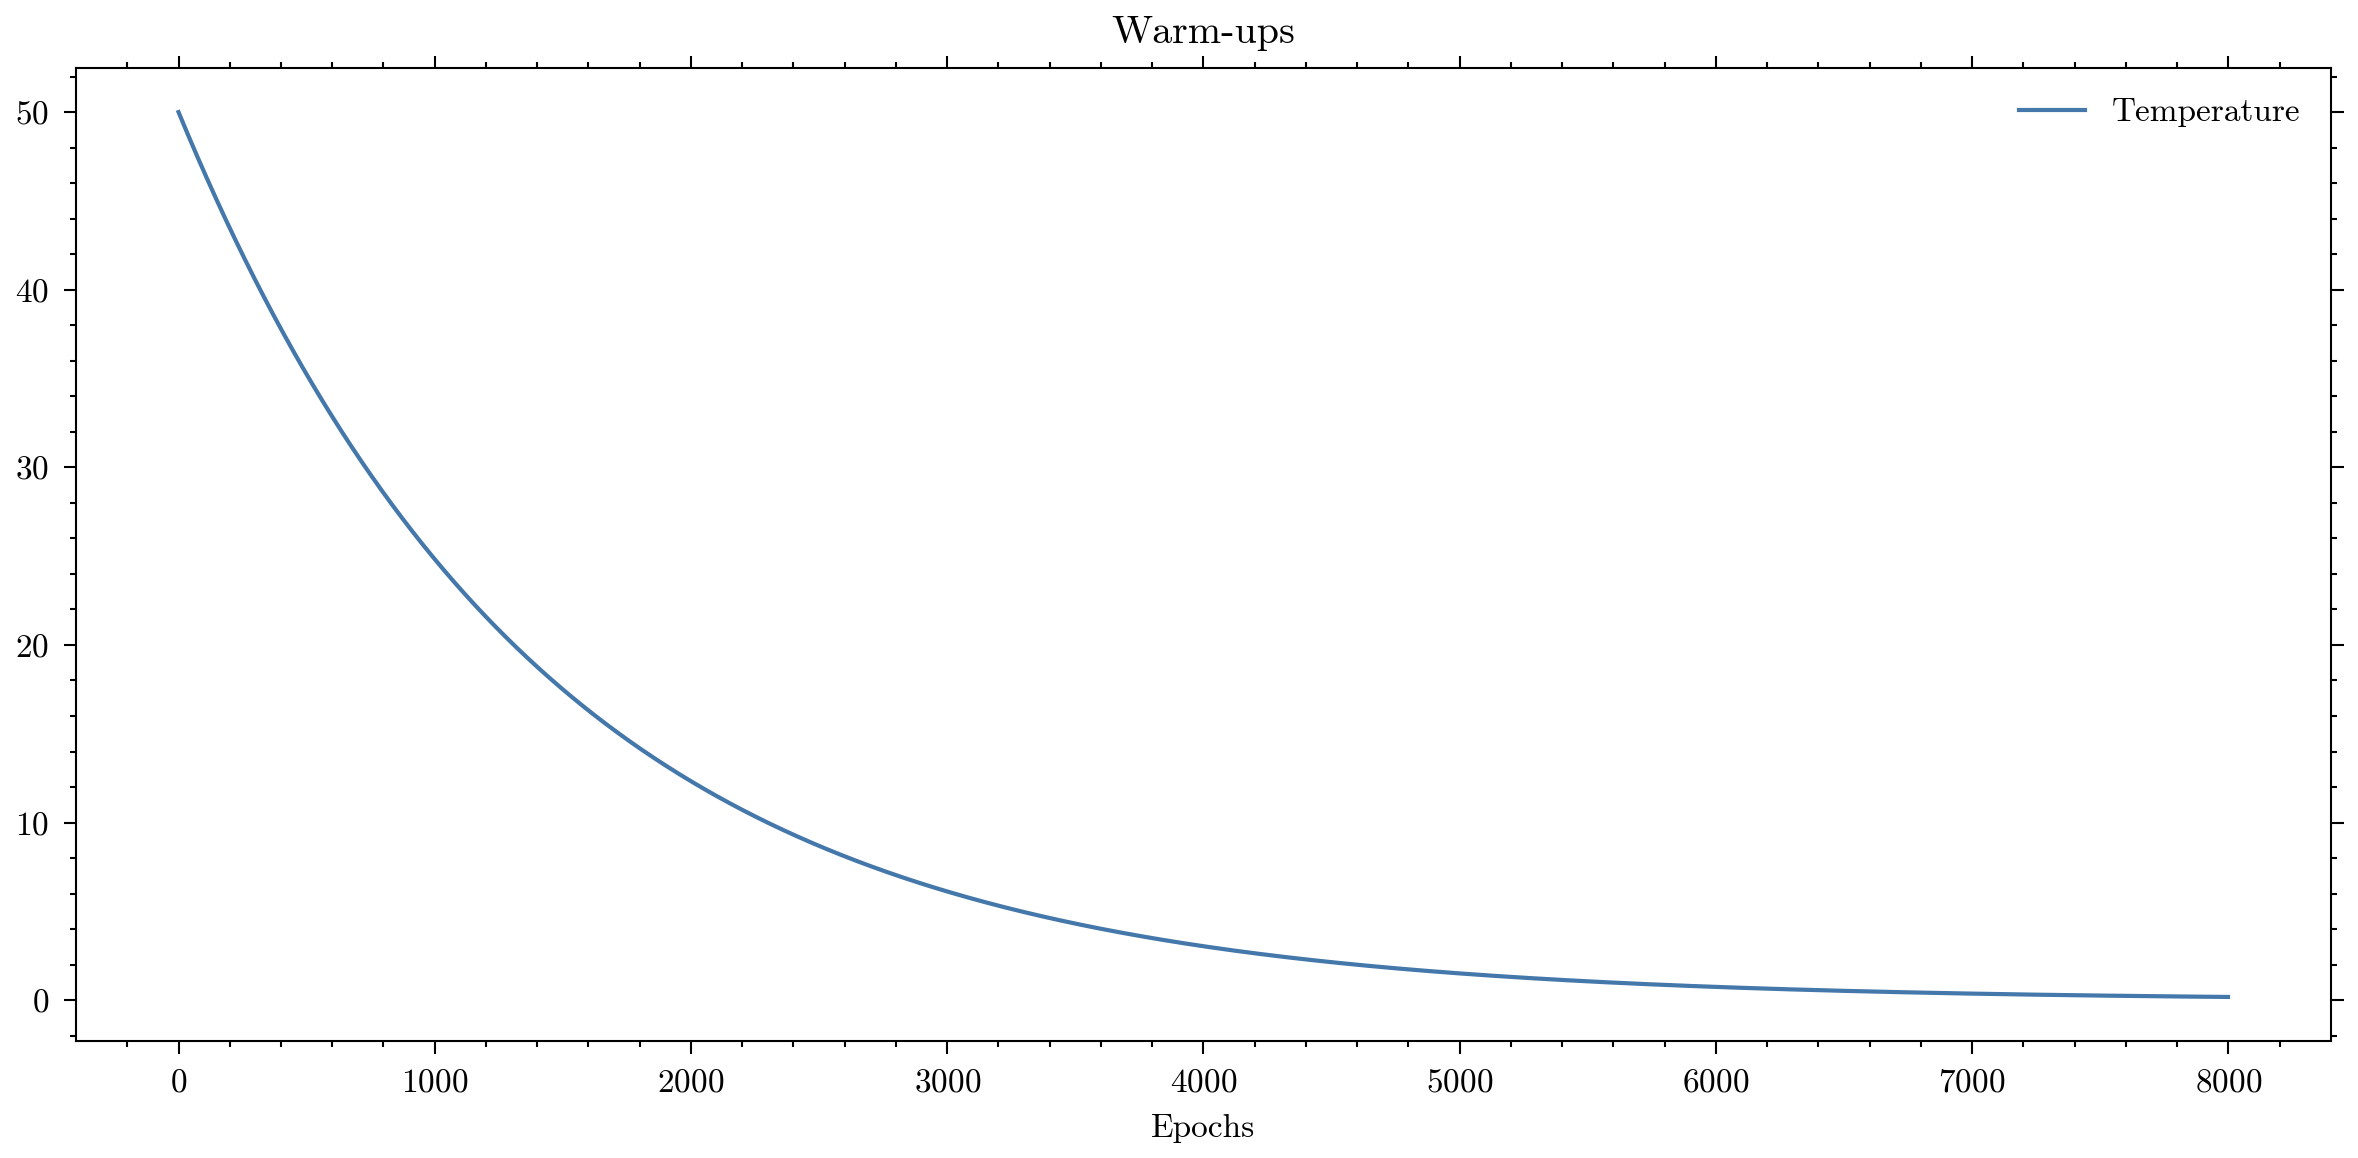

In [12]:
from amigo.fitting import batch_exposures
from amigo.calibration import temp_decay, cosine_warmup

# Get the batches: Calibrator, flats, and validators
batches = ois

n_epoch = 8000
n_batch = len(batches)


T0 = 5e1
decay = 0.0007

min_lr = 1.0
n_max = 3000  # Warm-up end

args = {
    "key": jr.key(0),  # RNG Key
    "t": np.array(0.0),  # Initial time step
    # "n_batch": np.array(n_batch, float),  # Number of batches
    "T0": np.array(T0),  # Initial temperature
    "k": np.array(decay),  # Decay rate
    "n_max": np.array(n_max),  # Warm-up end point
    "min_lr": np.array(min_lr),  # Minimum warm-up learning rate
}

ts = np.arange(n_epoch)
temps = temp_decay(args["T0"], args["k"], ts)
lrs = cosine_warmup(ts, args["T0"], args["n_max"])


plt.figure(figsize=(8, 4))
plt.title("Warm-ups")
plt.plot(ts, temps, label="Temperature")

plt.xlabel("Epochs")
plt.legend()

plt.tight_layout()
plt.show()

In [46]:
n_epoch = 8000
config = {
    "log_dist": adam(3e-3, 0),
    # "log_dist": adam(5e-4, 0),
    "contrast": sgd(2e-8, 0),
    # "log_dist": adam(5e-3, 0),
}
args = {
    "reg_dict": {
        # "ME": (0.0, ME),
        # "TV": (1e1, TV),
        "TV": (1e2, TV),
        # "TSV": (1e7, TSV),
        "ME": (5e2, ME),
        # "ME": (1e3, ME),
    },
    "key": jr.key(0),  # RNG Key
    "t": np.array(0.0),  # Initial time step
    "n_batch": np.array(len(ois), float),  # Number of batches
    "T0": np.array(T0),  # Initial temperature
    "k": np.array(decay),  # Decay rate
    # "n_max": np.array(n_max),  # Warm-up end point
    # "min_lr": np.array(min_lr),  # Minimum warm-up learning rate
}

trainer = Trainer(
    # loss_fn=centered_loss_fn,
    loss_fn=dorito.stats.regularised_loss_fn,
    norm_fn=normalise_distribution,
    looper_fn=looper,
    grad_fn=grads_fn,
)

trainer = trainer.update_fishers(
    model=model,
    exposures=[],
    parameters=[],
)

# Train the model
result = trainer.train(
    model=model,
    optimisers=config,
    epochs=n_epoch,
    batches=ois,
    args=args,
)

0it [00:00, ?it/s]

  0%|          | 0/8000 [00:00<?, ?it/s]

Compiling Loss function...
Compiling update function...

Initial_loss Loss: -2,175.55
Compiling Loss function...
Compiling update function...
Estimated run time: 3:45:36
Full Time: 0:02:28
Final Loss: -6,349.67


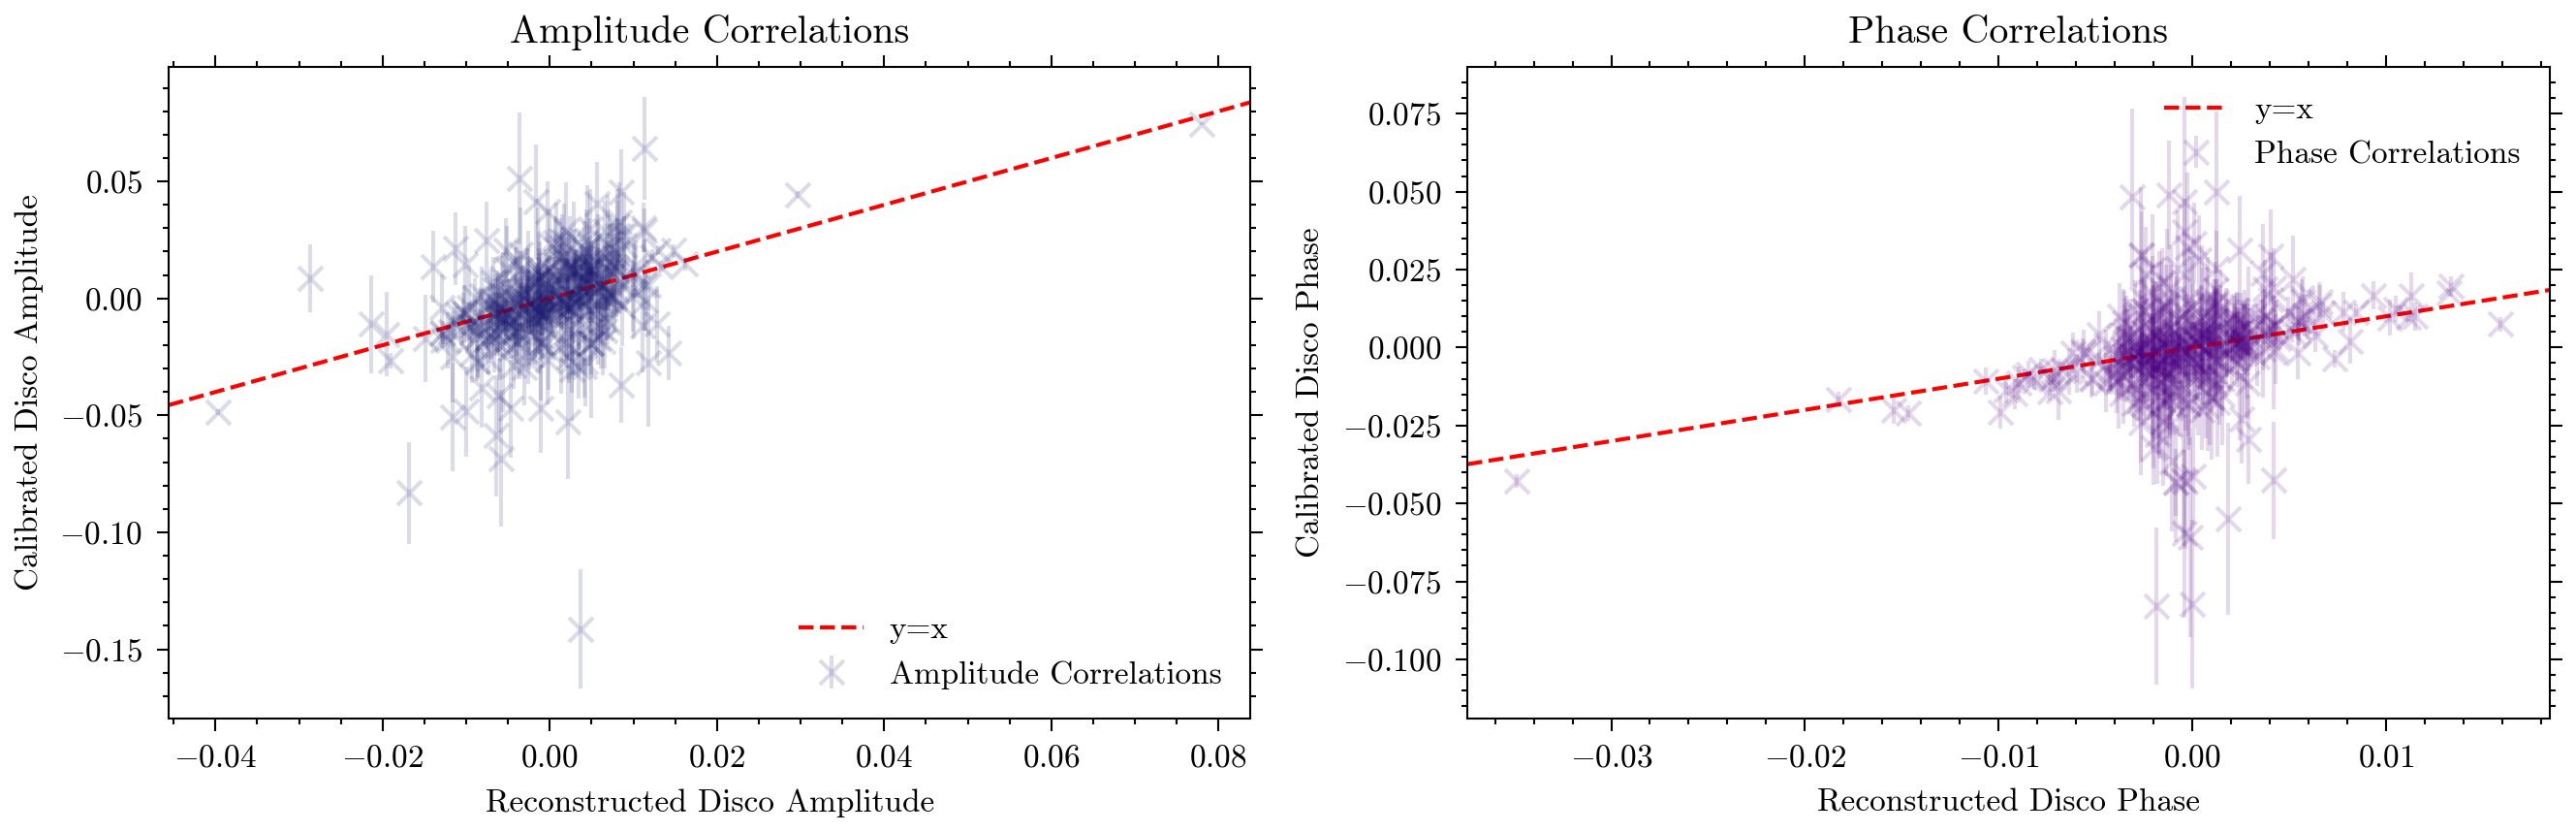

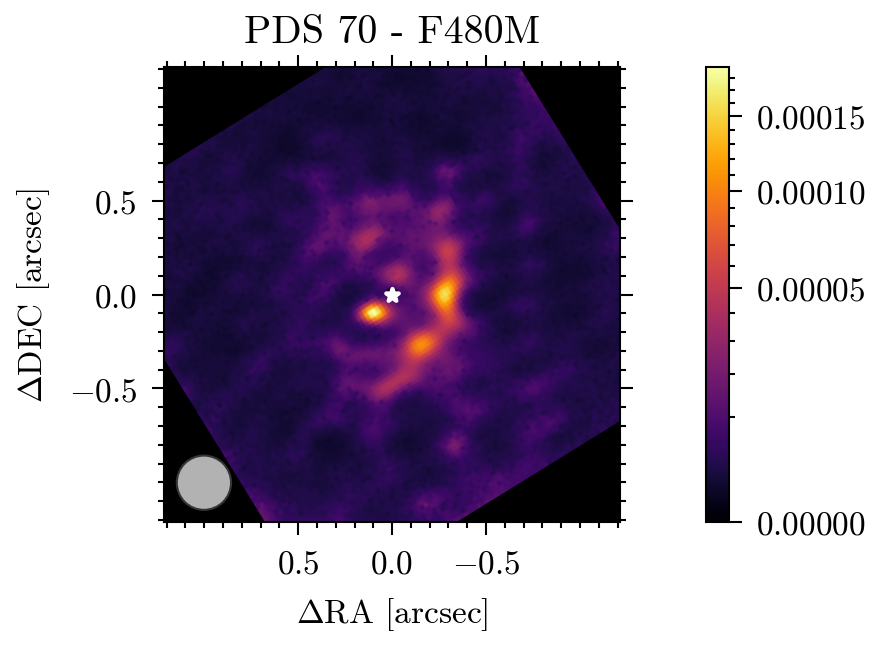

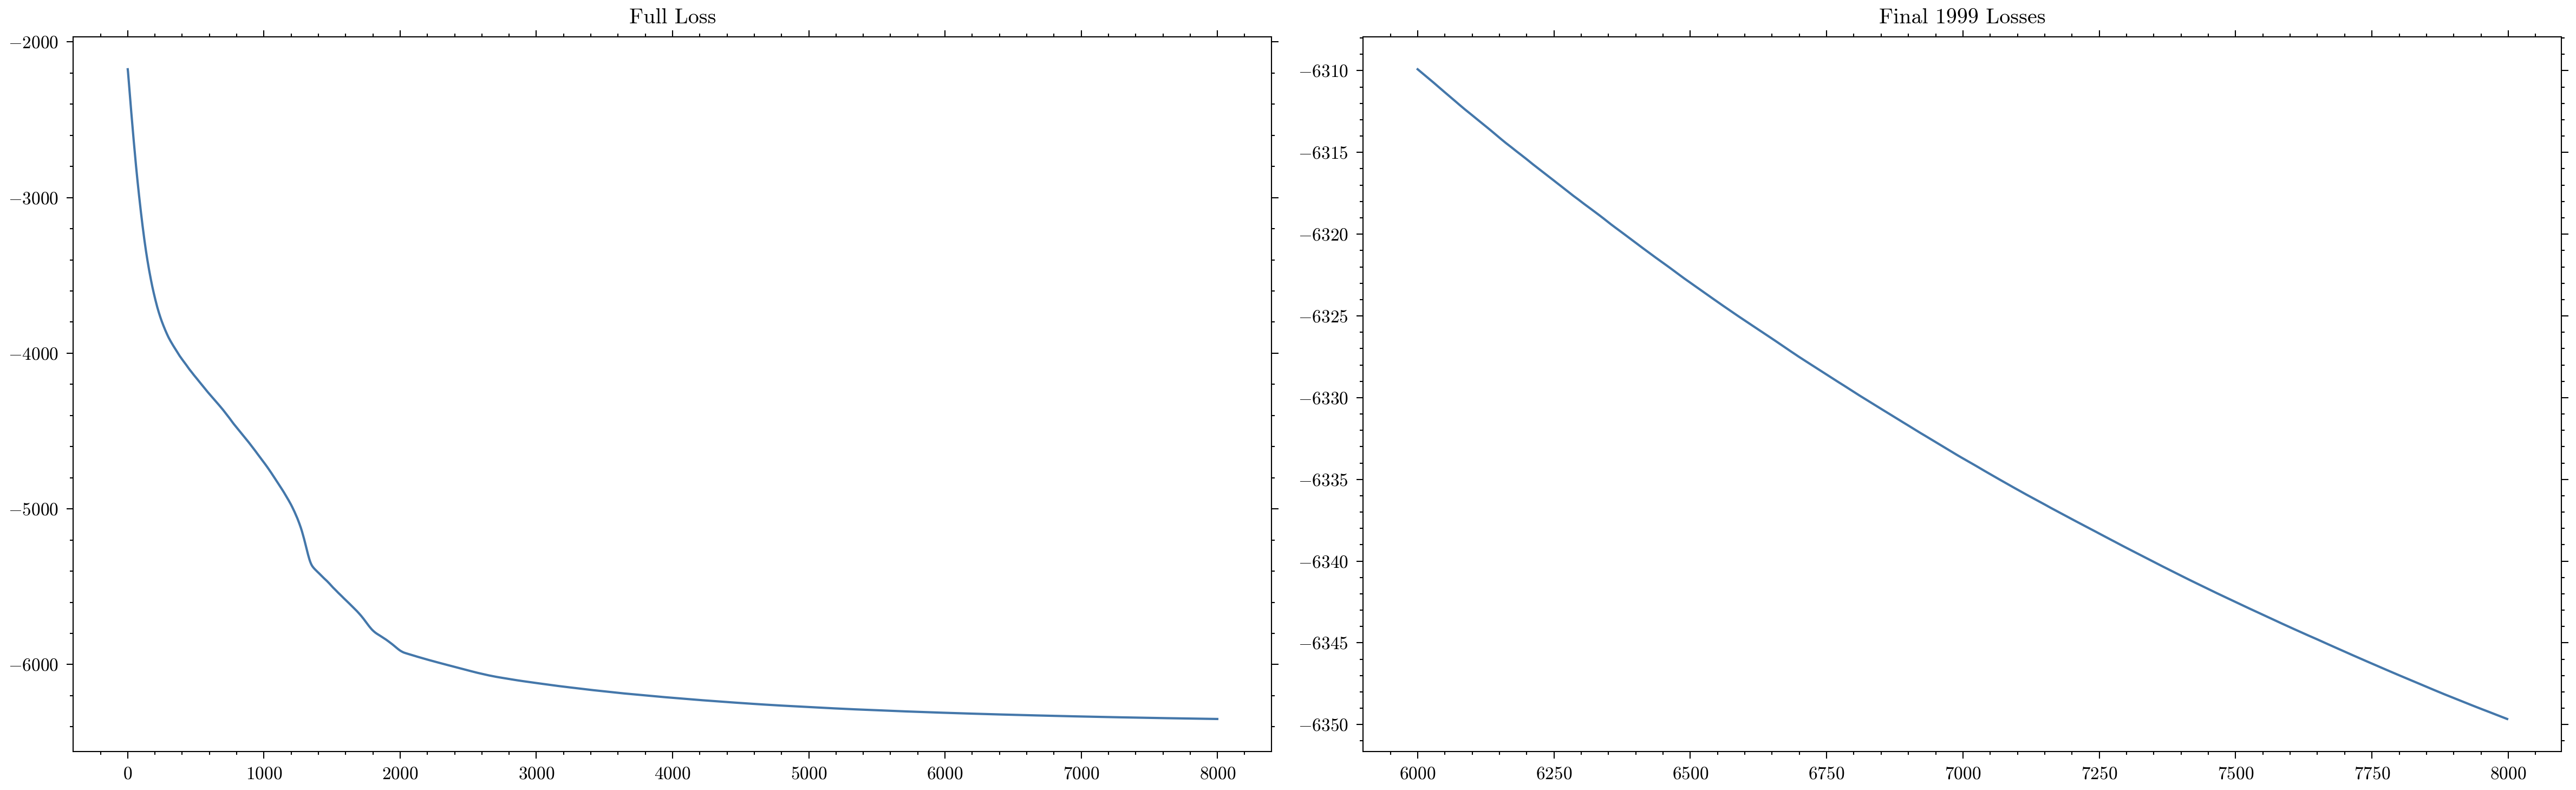

In [ ]:
from amigo import plotting

for oi in ois:
    dist = result.model(oi, rotate=False)

    disco_amp, disco_phase = np.split(oi(result.model), 2)

    # # PLOT THE CORRELATIONS

    fig, ax = plt.subplots(1, 2, figsize=(9, 3), sharey=False)

    ax[0].errorbar(
        disco_amp,
        oi.vis,
        yerr=oi.d_vis,
        label="Amplitude Correlations",
        fmt="x",
        alpha=0.15,
        color="midnightblue",
    )
    ax[0].axline((0, 0), slope=1, color="red", linestyle="--", label="y=x")
    ax[0].set_title("Amplitude Correlations")
    ax[0].set_xlabel("Reconstructed Disco Amplitude")
    ax[0].set_ylabel("Calibrated Disco Amplitude")
    ax[0].legend()

    ax[1].errorbar(
        disco_phase,
        oi.phi,
        yerr=oi.d_phi,
        label="Phase Correlations",
        fmt="x",
        alpha=0.15,
        color="indigo",
    )
    ax[1].axline((0, 0), slope=1, color="red", linestyle="--", label="y=x")
    ax[1].set_title("Phase Correlations")
    ax[1].set_xlabel("Reconstructed Disco Phase")
    ax[1].set_ylabel("Calibrated Disco Phase")
    ax[1].legend()

    plt.tight_layout()
    plt.show()

    # # PLOT THE DISTRIBUTINO

    fig, ax = plt.subplots(figsize=(6, 2.3))

    c0 = dorito.plotting.plot_result(
        ax,
        dist.at[model.size // 2, model.size // 2].set(np.nan),
        pixel_scale=dlu.rad2arcsec(model.pscale_in),
        cmap=inferno,
        norm=mpl.colors.PowerNorm(0.5, vmin=0),
        roll_angle_degrees=-oi.parang,
        diff_lim=dlu.rad2arcsec(oi.wavel / optics_diameter),
    )
    ax.scatter([0], [0], marker="*", color="white", s=10)

    fig.colorbar(c0)

    ax.set(
        title=f"PDS 70 - {oi.key}",
    )

    plt.tight_layout()
    plt.show()

plotting.plot_losses(result.losses[0], start=int(n_epoch * 0.75))
plotting.plot(result.history)

In [ ]:
import equinox as eqx
import optimistix as optx


def BFGS_logdist(
    model,
    exposures,
    reg_args,
    Solver=optx.BFGS,
    max_steps=2**16,
    rtol=1e-4,
    atol=1e-4,
):

    @eqx.filter_jit
    def fun(y, args):

        # unwrapping the args
        model, exp, reg_args = args

        # input is the log distribution
        log_dist, contrast = y

        # setting the model to the new log distribution
        params = model.params
        params["log_dist"][exp.get_key("log_dist")] = log_dist
        params["contrast"][exp.get_key("contrast")] = contrast
        model = model.set("params", params)

        # calculating loss
        loss, _ = dorito.stats.regularised_loss_fn(model, exp, reg_args)

        sum_prior = -jax.scipy.stats.norm.logpdf(
            model.get_distribution(exp).sum(), loc=1.0, scale=1e-5
        )

        return loss + sum_prior

    args_out = {}
    sols_out = {}
    for exp in exposures:

        X = (
            model.params["log_dist"][exp.get_key("log_dist")],
            model.params["contrast"][exp.get_key("contrast")],
        )
        args = (model, exp, reg_args)
        args_out[exp.key] = args

        print("Initial loss:", fun(X, args))
        solver = Solver(rtol=rtol, atol=atol)  # , verbose=frozenset({"loss"}))
        sol = optx.minimise(fun, solver, X, args, throw=False, max_steps=max_steps)
        sols_out[exp.key] = sol

        print("Final loss:", fun(sol.value, args))
        print(sol.stats["num_steps"], sol.state.num_accepted_steps)
        print(optx.RESULTS[sol.result])
        print()

    params = model.params
    for exp in ois:
        log_dist, contrast = sols_out[exp.key].value
        params["log_dist"][exp.get_key("log_dist")] = log_dist
        params["contrast"][exp.get_key("contrast")] = contrast

    return model.set("params", params)


def joint_solve(
    model,
    exposures,
    reg_args,
    Solver=optx.BFGS,
    max_steps=2**16,
    rtol=1e-4,
    atol=1e-4,
):

    @eqx.filter_jit
    def fun(y, args):

        # unwrapping the args
        model, exps, reg_args = args

        # input is the log distribution
        log_dist = y

        # setting the model to the new log distribution
        params = model.params
        params["log_dist"][exps[0].get_key("log_dist")] = log_dist
        model = model.set("params", params)

        # calculating loss
        loss = [
            dorito.stats.regularised_loss_fn(model, exp, reg_args)[0] for exp in exps
        ]
        loss = np.array(loss).mean()

        sum_prior = -jax.scipy.stats.norm.logpdf(
            model.get_distribution(exps[0]).sum(), loc=1.0, scale=1e-5
        )

        return loss + sum_prior

    args_out = {}
    sols_out = {}

    for filt in ["F380M", "F430M", "F480M"]:

        exps = [oi for oi in exposures if oi.filter == filt]
        for exp in exps:
            print(exp.key)

        if len(exps) == 0:
            print(f"No exposures for filter {filt}, skipping initialisation.")
            continue

        X = model.params["log_dist"][filt]
        _args = (model, exps, reg_args)
        args_out[filt] = _args

        print("Initial loss:", fun(X, _args))
        solver = Solver(rtol=rtol, atol=atol)
        sol = optx.minimise(fun, solver, X, _args, throw=False, max_steps=max_steps)
        sols_out[filt] = sol

        print("Final loss:", fun(sol.value, _args))
        print(sol.stats["num_steps"], sol.state.num_accepted_steps)
        print(optx.RESULTS[sol.result])
        print()

    params = {"log_dist": {}, "base_uv": model.params["base_uv"]}
    for exp in ois:
        log_dist = sols_out[exp.filter].value
        params["log_dist"][exp.get_key("log_dist")] = log_dist

    return model.set("params", params)

In [ ]:
final_model = result.model


bfgs_model = BFGS_logdist(
    final_model,
    # model,
    ois,
    args,
    Solver=optx.BFGS,
    max_steps=2**16,
    rtol=1e-10,
    atol=1e-10,
)


# bfgs_model = joint_solve(
#     model,
#     # final_model,
#     ois,
#     args,
#     Solver=optx.LevenbergMarquardt,
#     max_steps=2**14,
#     rtol=1e-6,
#     atol=1e-6,
# )

# for oi in ois:
#     sol = sols_out[oi.filter]
#     print(oi.key)
#     print("Final loss:", fun(sol.value, _args))
#     # print(sol.result)

Initial loss: -6362.160255674903
Final loss: -6380.595004055652
5473 872




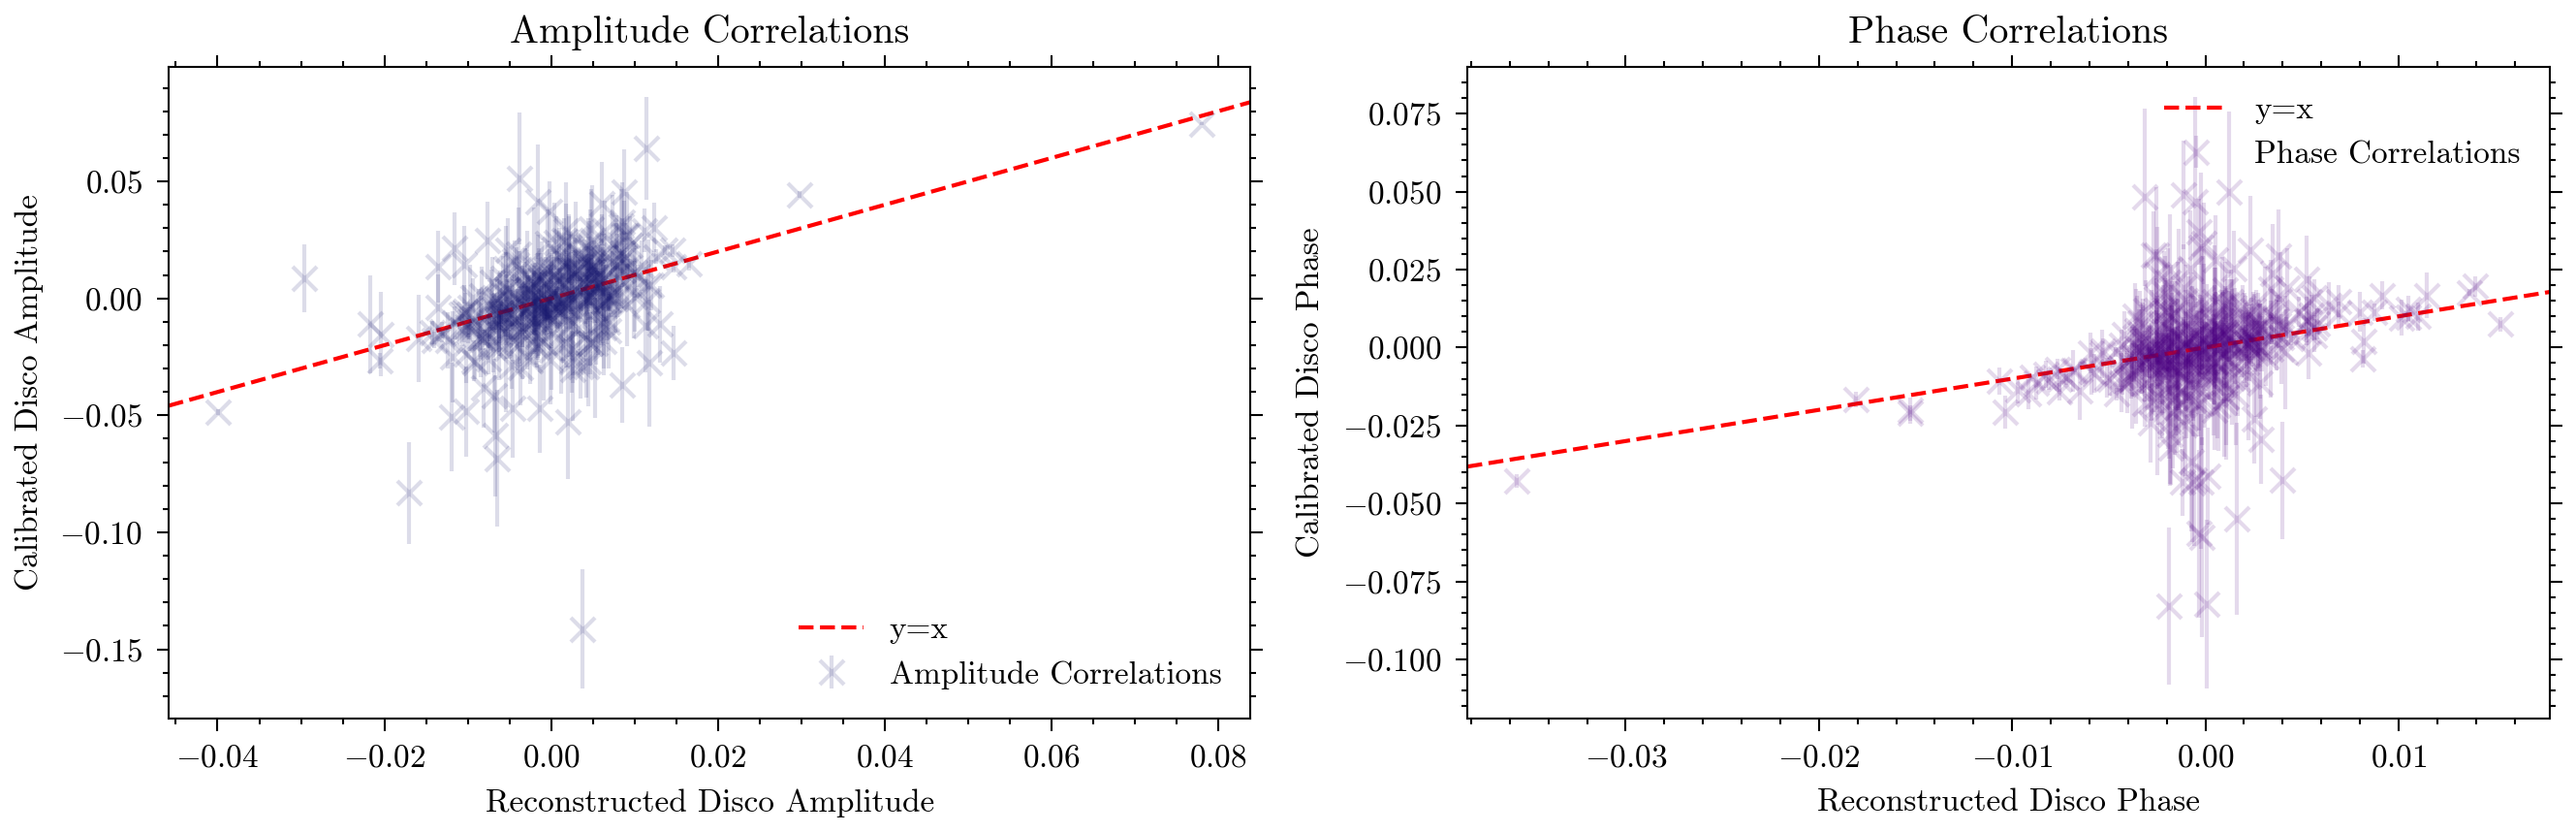

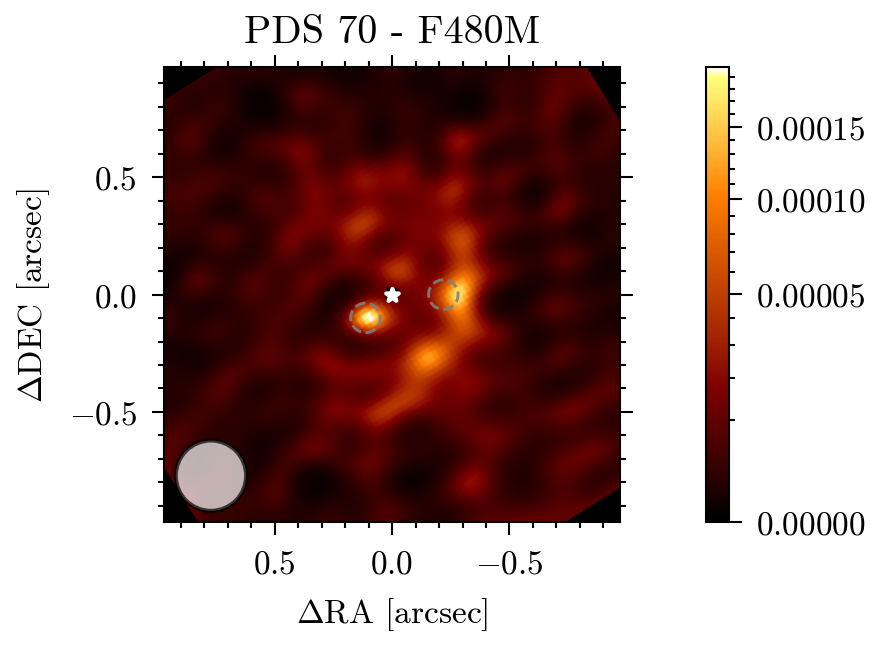

In [ ]:
for oi in ois:

    disco_amp, disco_phase = np.split(oi(bfgs_model), 2)

    # # PLOT THE CORRELATIONS

    fig, ax = plt.subplots(1, 2, figsize=(9, 3), sharey=False)

    ax[0].errorbar(
        disco_amp,
        oi.vis,
        yerr=oi.d_vis,
        label="Amplitude Correlations",
        fmt="x",
        alpha=0.15,
        color="midnightblue",
    )
    ax[0].axline((0, 0), slope=1, color="red", linestyle="--", label="y=x")
    ax[0].set_title("Amplitude Correlations")
    ax[0].set_xlabel("Reconstructed Disco Amplitude")
    ax[0].set_ylabel("Calibrated Disco Amplitude")
    ax[0].legend()

    ax[1].errorbar(
        disco_phase,
        oi.phi,
        yerr=oi.d_phi,
        label="Phase Correlations",
        fmt="x",
        alpha=0.15,
        color="indigo",
    )
    ax[1].axline((0, 0), slope=1, color="red", linestyle="--", label="y=x")
    ax[1].set_title("Phase Correlations")
    ax[1].set_xlabel("Reconstructed Disco Phase")
    ax[1].set_ylabel("Calibrated Disco Phase")
    ax[1].legend()

    plt.tight_layout()
    plt.show()

    dist = bfgs_model.get_distribution(oi, rotate=False, with_star=False)
    dist = dist / bfgs_model.params["contrast"][oi.get_key("contrast")]

    # vmin = 1 / (2.5**7.8)
    vmin = 0
    # # PLOT THE DISTRIBUTINO

    fig, ax = plt.subplots(figsize=(6, 2.3))

    c0 = dorito.plotting.plot_result(
        ax,
        dist,
        pixel_scale=dlu.rad2arcsec(model.pscale_in),
        cmap="afmhot_u",
        # cmap=inferno,
        norm=mpl.colors.PowerNorm(0.5, vmin=vmin),
        roll_angle_degrees=-oi.parang,
        diff_lim=dlu.rad2arcsec(oi.wavel / optics_diameter),
        scale=1.25,
    )
    ax.scatter([0], [0], marker="*", color="white", s=10)

    seps = 1e-3 * np.array([150.5, 218.4])
    pas = np.array([131.2, 270.0])
    xs = seps * np.cos(np.radians(pas))
    ys = seps * np.sin(np.radians(pas))
    ax.scatter(
        ys,
        xs,
        marker="o",
        alpha=0.9,
        s=50,
        facecolors="none",
        edgecolors="grey",
        linestyle="--",
        linewidths=0.7,
    )

    fig.colorbar(c0)

    ax.set(
        title=f"PDS 70 - {oi.key}",
    )

    plt.tight_layout()
    plt.show()

In [18]:
r = bfgs_model.get_distribution(ois[2], with_star=False)
g = bfgs_model.get_distribution(ois[1], with_star=False)
b = bfgs_model.get_distribution(ois[0], with_star=False)

# r = result.model.get_distribution(ois[2], with_star=False)
# g = result.model.get_distribution(ois[1], with_star=False)
# b = result.model.get_distribution(ois[0], with_star=False)

r /= r.max()
g /= g.max()
b /= b.max()
p = 1.0

r = r**p
g = g**p
b = b**p

piccy = np.stack([r, g, b], axis=-1)

fig, ax = plt.subplots(figsize=(3, 3))

c0 = dorito.plotting.plot_result(
    ax,
    piccy,
    pixel_scale=dlu.rad2arcsec(model.pscale_in),
    roll_angle_degrees=-oi.parang,
    scale=1.25,
    diff_lim=dlu.rad2arcsec(
        np.array([oi.wavel for oi in ois]).mean() / optics_diameter
    ),
    ticks=[-0.5, 0, 0.5],
)

seps = 1e-3 * np.array([150.5, 218.4])
pas = np.array([131.2, 270.0])
xs = seps * np.cos(np.radians(pas))
ys = seps * np.sin(np.radians(pas))
ax.scatter(
    ys,
    xs,
    marker="o",
    alpha=0.9,
    s=80,
    facecolors="none",
    edgecolors="grey",
    linestyle="--",
    linewidths=0.7,
)
ax.scatter([0], [0], marker="*", color="white", s=10)
ax.set(
    title=f"PDS70 - False Colour",
)
plt.tight_layout()
plt.show()

IndexError: list index out of range

In [ ]:
# np.save("files/71pix_os5.npy", bfgs_model.params, allow_pickle=True)
# np.save(output_path + "71pix_os5.npy", bfgs_model.params, allow_pickle=True)
# np.save(output_path + "121pix_os8.npy", bfgs_model.params, allow_pickle=True)

# params = np.load(output_path + "121pix_os8.npy", allow_pickle=True).item()
# bfgs_model = model.set("params", params)

1.0000000070135724
Loss: -2.756e+03


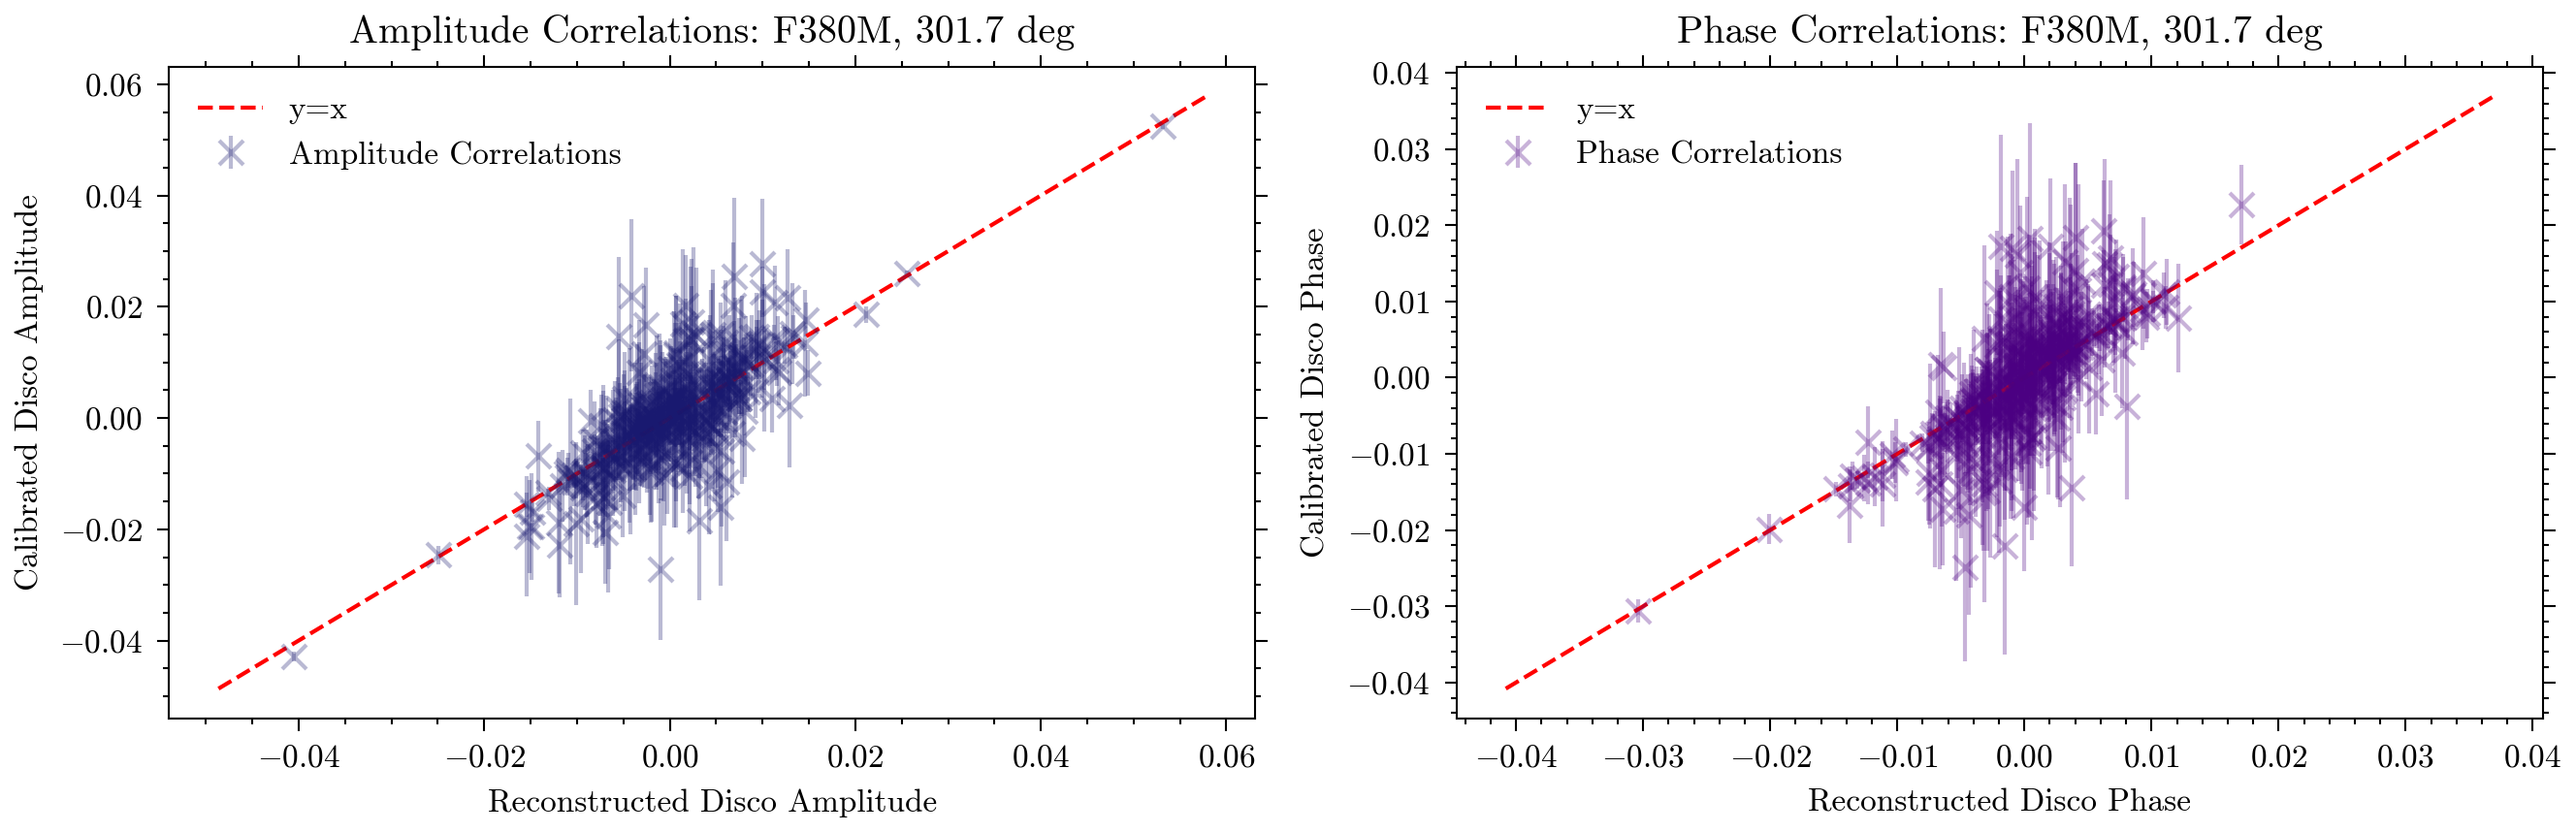

TypeError: plot_result() got an unexpected keyword argument 'power'

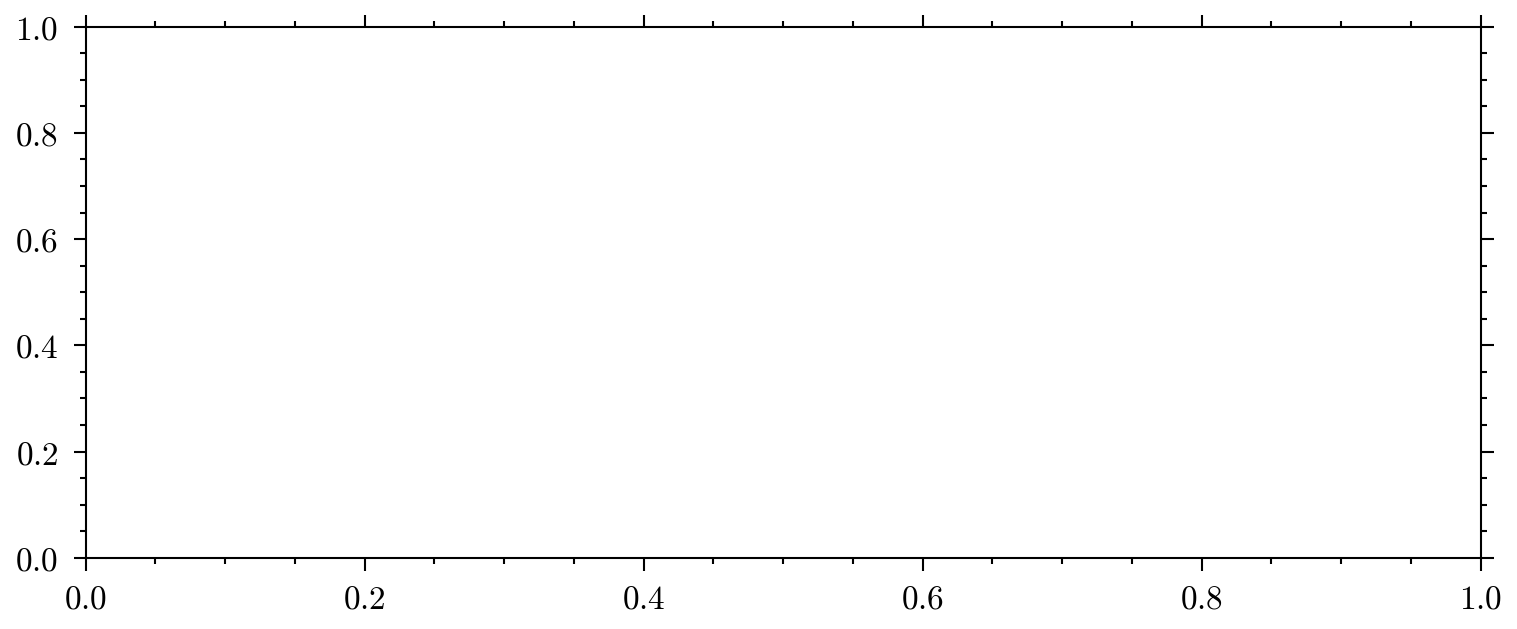

In [ ]:
for oi in ois:

    print(bfgs_model.get_distribution(oi).sum())
    # print(phase_centre(bfgs_model, oi))
    loss = dorito.stats.regularised_loss_fn(bfgs_model, oi, args)[0]
    print(f"Loss: {loss:.3e}")

    dist = bfgs_model.get_distribution(oi, rotate=False, with_star=False)

    disco_amp, disco_phase = np.split(oi(bfgs_model), 2)

    fig, ax = plt.subplots(1, 2, figsize=(9, 3), sharey=False)

    ax[0].errorbar(
        disco_amp,
        oi.vis,
        yerr=oi.d_vis,
        label="Amplitude Correlations",
        fmt="x",
        alpha=0.3,
        color="midnightblue",
    )
    x_min, x_max = ax[0].get_xlim()
    y_min, y_max = ax[0].get_ylim()
    min_val = min(x_min, y_min)
    max_val = max(x_max, y_max)
    ax[0].plot([min_val, max_val], [min_val, max_val], "r--", label="y=x")
    ax[0].set_title(f"Amplitude Correlations: {oi.filter}, {oi.parang:.1f} deg")
    ax[0].set_xlabel("Reconstructed Disco Amplitude")
    ax[0].set_ylabel("Calibrated Disco Amplitude")
    ax[0].legend()

    ax[1].errorbar(
        disco_phase,
        oi.phi,
        yerr=oi.d_phi,
        label="Phase Correlations",
        fmt="x",
        alpha=0.3,
        color="indigo",
    )
    x_min, x_max = ax[1].get_xlim()
    y_min, y_max = ax[1].get_ylim()
    min_val = min(x_min, y_min)
    max_val = max(x_max, y_max)
    ax[1].plot([min_val, max_val], [min_val, max_val], "r--", label="y=x")
    ax[1].set_title(f"Phase Correlations: {oi.filter}, {oi.parang:.1f} deg")
    ax[1].set_xlabel("Reconstructed Disco Phase")
    ax[1].set_ylabel("Calibrated Disco Phase")
    ax[1].legend()

    plt.tight_layout()
    plt.show()

    ticks = [-0.5, 0, 0.5]

    fig, ax = plt.subplots(figsize=(6, 2.3))

    c0 = dorito.plotting.plot_result(
        ax,
        dist,
        pixel_scale=dlu.rad2arcsec(model.pscale_in),
        cmap=inferno,
        power=0.5,
        vmin=0,
        roll_angle_degrees=-oi.parang,
    )
    ax.scatter([0], [0], marker="*", color="white", s=10)

    fig.colorbar(c0)

    ax.set(
        title=f"PDS 70 - {oi.key}",
        xticks=ticks,
        yticks=ticks,
    )

    plt.tight_layout()
    plt.show()

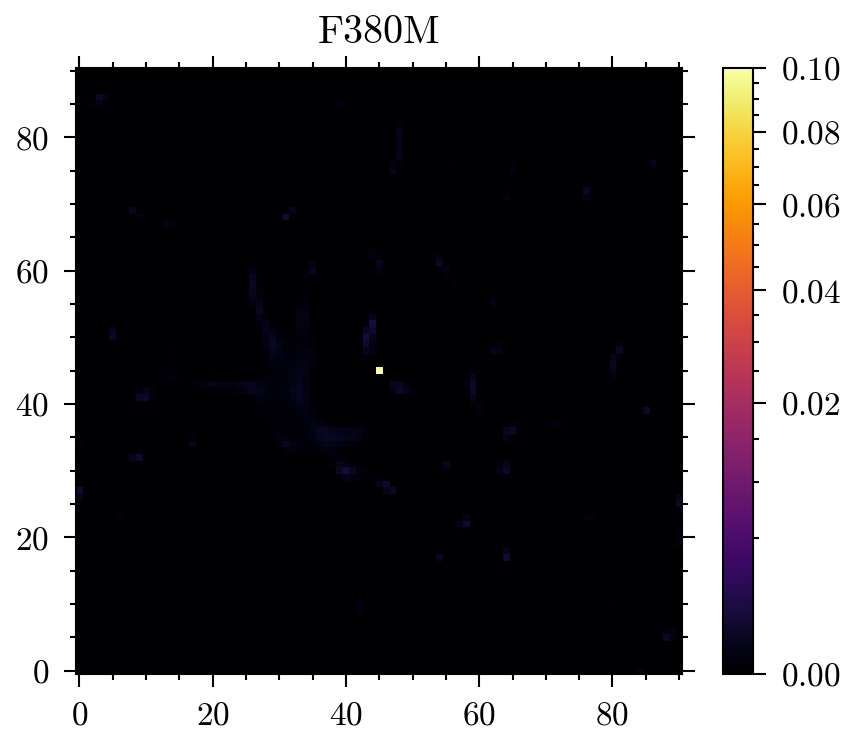

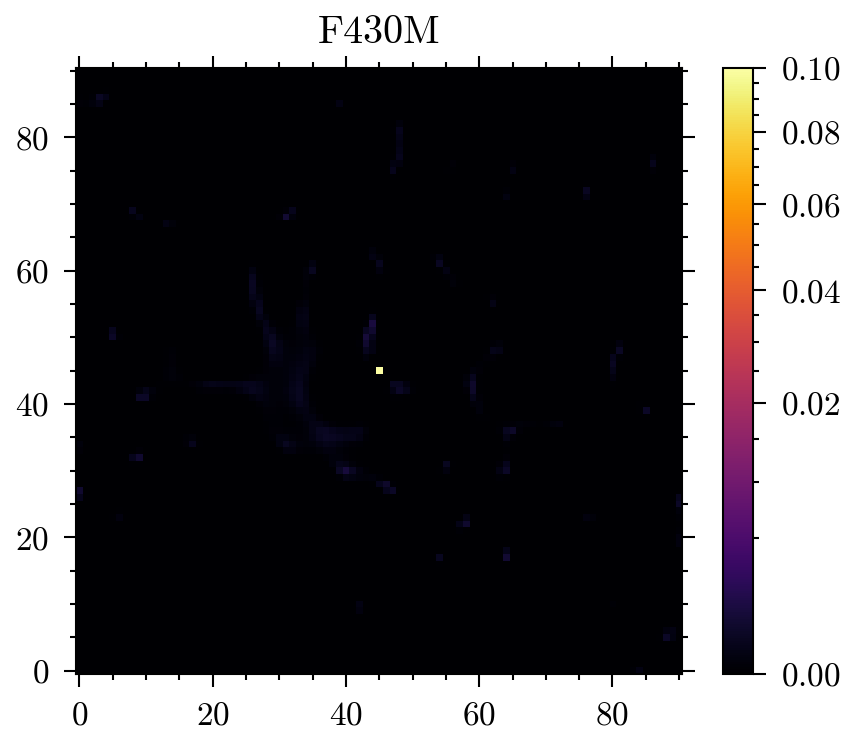

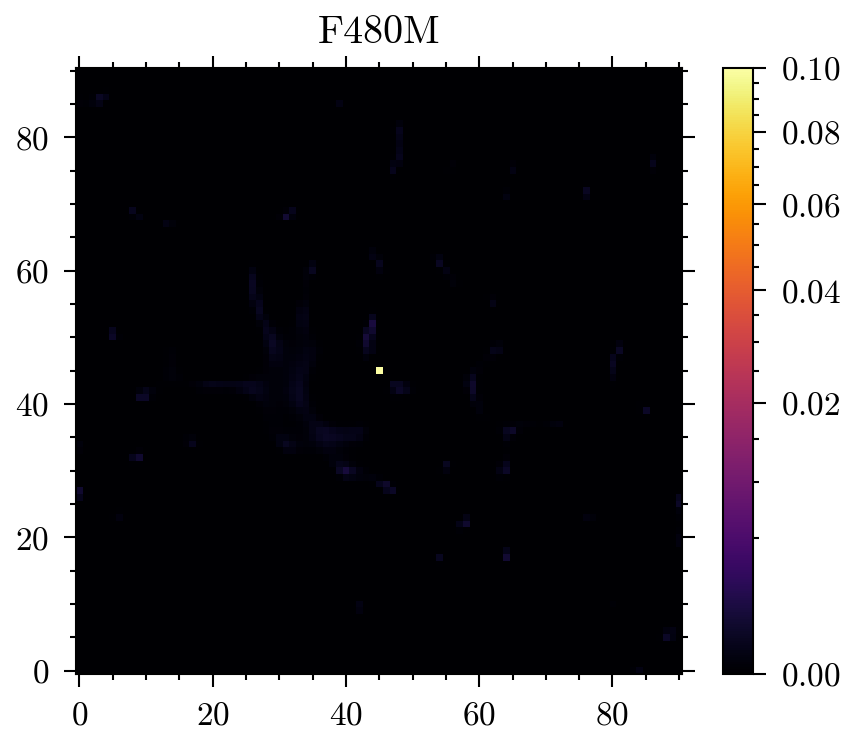

In [ ]:
for filt in ["F380M", "F430M", "F480M"]:
    dist = bfgs_model.get_distribution(oi, rotate=False)

    rl_dist = np.clip(dist + 1e-16)
    rl_dist = rl_dist / rl_dist.max()

    rl_dist = np.rot90(rl_dist, 2)
    plt.imshow(rl_dist, norm=mpl.colors.PowerNorm(0.5, vmin=0, vmax=1e-1))
    plt.title(filt)
    plt.colorbar()
    plt.show()